In [ ]:
# ============================================================
#   📌 STEP 0: COLAB ENVIRONMENT SETUP
#   - Ensures outputs are saved persistently
#   - Ignores warnings for cleaner output (optional)
# ============================================================

import os
# Create the output directory if it doesn't exist. This is CRITICAL for Colab.
# All generated plots will be saved here. You can download this folder later.
os.makedirs("/mnt/user-data/outputs/ml_pipeline", exist_ok=True)

# Optional: Suppress warnings to keep the output clean and focused on results.
import warnings
warnings.filterwarnings("ignore")

# Print the current working directory to confirm where you are.
print(f"✅ Output directory created: /mnt/user-data/outputs/ml_pipeline")
print(f"Current working directory: {os.getcwd()}")

✅ Output directory created: /mnt/user-data/outputs/ml_pipeline
Current working directory: /content


In [ ]:
# ============================================================
#   📌 STEP 1: IMPORT LIBRARIES
#   - numpy: Numerical operations (arrays, math)
#   - pandas: Data manipulation (DataFrames, analysis)
#   - matplotlib/seaborn: Plotting (visualization is KEY for portfolios!)
#   - scikit-learn: THE ML library (datasets, models, metrics, tools)
# ============================================================

# --- Data Science Core ---
import numpy as np          # For efficient numerical arrays & math
import pandas as pd         # For tabular data manipulation & analysis

# --- Visualization (Makes your portfolio SHINE) ---
import matplotlib
matplotlib.use("Agg")      # Non-interactive backend for saving plots headlessly (essential for Colab)
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec  # For complex multi-plot layouts (dashboard)
import seaborn as sns       # Statistical plotting on top of matplotlib (beautiful heatmaps, etc.)

# --- Scikit-Learn: The ML Engine ---
from sklearn.datasets import load_iris, load_breast_cancer  # Built-in clean datasets
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold  # SPLITTING & VALIDATION
from sklearn.preprocessing import StandardScaler, label_binarize  # DATA PREPROCESSING
from sklearn.pipeline import Pipeline  # (Not used here but good practice)

# --- Models (The "brain" of the project) ---
from sklearn.ensemble import RandomForestClassifier  # Robust, non-linear, handles features well
from sklearn.svm import SVC                           # Powerful for complex boundaries (needs scaling)
from sklearn.linear_model import LogisticRegression   # Simple, interpretable, baseline model (needs scaling)

# --- Metrics & Evaluation (How we judge performance) ---
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,  # Core classification metrics
    classification_report, confusion_matrix,                  # Detailed diagnostics
    roc_curve, auc, roc_auc_score                            # **CRITICAL for binary classification**
)
from sklearn.multiclass import OneVsRestClassifier  # (For multi-class ROC, if needed)
from itertools import cycle  # (For plotting multiple ROC curves)

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


In [ ]:
# ============================================================
#   📌 STEP 2: PLOT STYLE CONFIGURATION
#   - Sets a modern, consistent visual theme
#   - Defines colors for each model (used across ALL plots)
#   - Makes your portfolio look polished and intentional
# ============================================================

# Update matplotlib defaults for ALL plots
plt.rcParams.update({
    "figure.dpi": 150,          # High resolution for crisp images
    "font.family": "DejaVu Sans",  # Clean, modern font
    "axes.spines.top": False,   # Remove top/right borders for cleaner look
    "axes.spines.right": False,
})

# Color palette: Consistent colors for each model throughout the project
# This is a BEST PRACTICE for multi-model comparisons.
PALETTE = {
    "Random Forest":       "#4CAF50",  # Green
    "SVM":                 "#2196F3",  # Blue
    "Logistic Regression": "#FF9800",  # Orange
}

# Separator for console output readability
SECTION_SEP = "=" * 65

print("✅ Plot style configured. Colors assigned to models.")

✅ Plot style configured. Colors assigned to models.


In [ ]:
# ============================================================
#   📌 STEP 3: HELPER FUNCTIONS (DRY Principle: Don't Repeat Yourself)
#   - print_section: Clean console headers
#   - evaluate_model: Calculates ALL metrics in one place
#   - plot_confusion_matrix: Reusable, beautiful heatmap generator
# ============================================================

def print_section(title):
    """Prints a formatted section header to the console."""
    print(f"\n{SECTION_SEP}")
    print(f"  {title}")
    print(SECTION_SEP)

def evaluate_model(name, model, X_test, y_test, average="weighted"):
    """
    Calculates key performance metrics for a trained model.
    'average'="weighted" for multi-class, "binary" for binary classification.
    """
    y_pred = model.predict(X_test)  # Generate predictions
    return {
        "Model": name,
        "Accuracy":  round(accuracy_score(y_test, y_pred), 4),
        "Precision": round(precision_score(y_test, y_pred, average=average, zero_division=0), 4),
        "Recall":    round(recall_score(y_test, y_pred, average=average, zero_division=0), 4),
        "F1-Score":  round(f1_score(y_test, y_pred, average=average, zero_division=0), 4),
    }

def plot_confusion_matrix(cms, names, class_names, title, save_path):
    """
    Plots side-by-side confusion matrices for multiple models.
    'cms' is a list of confusion matrices, 'names' is a list of model names.
    """
    n = len(cms)
    fig, axes = plt.subplots(1, n, figsize=(6 * n, 5))
    fig.patch.set_facecolor("#0F1117")  # Dark background

    if n == 1:
        axes = [axes]  # Handle single model case

    for ax, cm, name in zip(axes, cms, names):
        color = PALETTE[name]
        # Mask diagonal to avoid highlighting correct predictions (optional)
        mask_diag = np.zeros_like(cm, dtype=bool)
        np.fill_diagonal(mask_diag, True)

        # Create heatmap
        cmap = sns.light_palette(color, as_cmap=True)
        sns.heatmap(
            cm, annot=True, fmt="d", cmap=cmap,
            xticklabels=class_names, yticklabels=class_names,
            linewidths=0.5, linecolor="#333",
            ax=ax, cbar=True, annot_kws={"size": 12, "weight": "bold"}
        )
        ax.set_title(name, color=color, fontsize=13, fontweight="bold", pad=10)
        ax.set_xlabel("Predicted Label", color="#CCCCCC", fontsize=10)
        ax.set_ylabel("True Label", color="#CCCCCC", fontsize=10)
        ax.tick_params(colors="#AAAAAA")
        ax.set_facecolor("#1A1A2E")
        for spine in ax.spines.values():
            spine.set_edgecolor("#333")

    fig.suptitle(title, color="white", fontsize=15, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.savefig(save_path, bbox_inches="tight", facecolor=fig.get_facecolor())
    plt.close()
    print(f"  ✅ Saved → {save_path}")

print("✅ Helper functions defined. Ready for data!")

✅ Helper functions defined. Ready for data!


In [ ]:
# ============================================================
#   📌 STEP 4.1: LOAD & EXPLORE IRIS DATASET
#   - 3 classes (Setosa, Versicolor, Virginica)
#   - 4 features (sepal/petal length/width)
#   - GOAL: Visualize separability & check class balance
# ============================================================

print_section("SECTION 1 · IRIS DATASET  (Multi-Class: 3 Species)")

# Load the built-in dataset
iris = load_iris()
X_iris, y_iris = iris.data, iris.target  # Features, Labels
class_names_iris = iris.target_names      # ['setosa', 'versicolor', 'virginica']
feature_names_iris = iris.feature_names    # ['sepal length (cm)', ...]

# --- Basic Data Info (Essential for EDA) ---
print(f"  Dataset shape : {X_iris.shape}")  # (150, 4) - 150 samples, 4 features
print(f"  Classes       : {list(class_names_iris)}")
print(f"  Class balance : {dict(zip(class_names_iris, np.bincount(y_iris)))}")  # Check for imbalance!

# --- Visualize Feature Distributions (PAIR PLOT) ---
# This 2x2 grid shows how features relate and how classes separate.
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.patch.set_facecolor("#0F1117")

# Convert to DataFrame for easier plotting with seaborn
df_iris = pd.DataFrame(X_iris, columns=feature_names_iris)
df_iris["species"] = [class_names_iris[i] for i in y_iris]  # Add class names

# Define colors for each class (consistent with PALETTE)
colors_iris = ["#4CAF50", "#2196F3", "#FF9800"]

# Loop through two key feature pairs
for ax, (feat_x, feat_y) in zip(
    axes,
    [
        ("petal length (cm)", "petal width (cm)"),  # Most separable features
        ("sepal length (cm)", "sepal width (cm)"),
    ],
):
    # Plot each class separately
    for i, sp in enumerate(class_names_iris):
        sub = df_iris[df_iris["species"] == sp]
        ax.scatter(sub[feat_x], sub[feat_y], label=sp, color=colors_iris[i],
                   alpha=0.8, edgecolors="white", linewidths=0.4, s=60)
    ax.set_xlabel(feat_x, color="#CCCCCC")
    ax.set_ylabel(feat_y, color="#CCCCCC")
    ax.set_title(f"{feat_x.split(' ')[0].title()} vs {feat_y.split(' ')[0].title()}",
                 color="white", fontweight="bold")
    ax.set_facecolor("#1A1A2E")
    ax.legend(facecolor="#222", labelcolor="white", framealpha=0.8)
    ax.tick_params(colors="#AAAAAA")

fig.suptitle("🌸 Iris Dataset — Feature Distribution by Species",
             color="white", fontsize=14, fontweight="bold")
plt.tight_layout()
# Save the plot
plt.savefig("/mnt/user-data/outputs/ml_pipeline/iris_distribution.png",
            bbox_inches="tight", facecolor=fig.get_facecolor())
plt.close()
print("  ✅ Saved → iris_distribution.png (EDA: Shows data separability)")


  SECTION 1 · IRIS DATASET  (Multi-Class: 3 Species)
  Dataset shape : (150, 4)
  Classes       : [np.str_('setosa'), np.str_('versicolor'), np.str_('virginica')]
  Class balance : {np.str_('setosa'): np.int64(50), np.str_('versicolor'): np.int64(50), np.str_('virginica'): np.int64(50)}
  ✅ Saved → iris_distribution.png (EDA: Shows data separability)


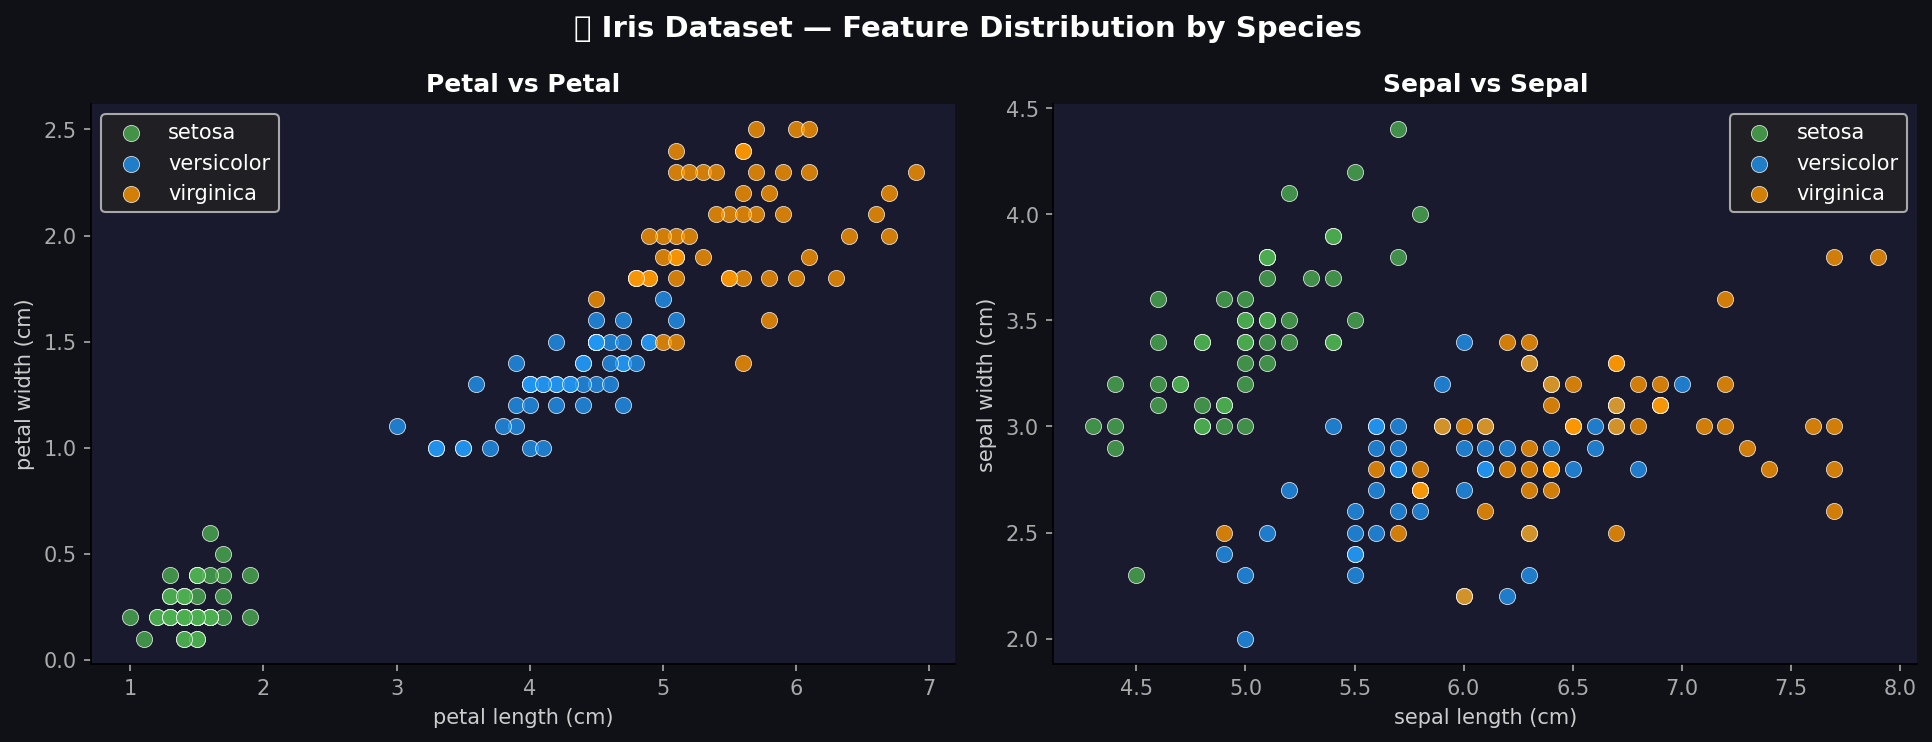

In [ ]:
# ============================================================
#   📌 STEP 4.2: TRAIN / TEST SPLIT WITH STRATIFICATION
#   - 80% Train, 20% Test (standard split)
#   - stratify=y_iris: MAINTAINS original class ratios in BOTH sets
#   - random_state=42: Reproducibility (same split every time)
# ============================================================

# Split the data: 80% training, 20% testing
X_train_i, X_test_i, y_train_i, y_test_i = train_test_split(
    X_iris, y_iris, test_size=0.20, random_state=42, stratify=y_iris  # <-- KEY: Stratify!
)

print(f"\n  Train size: {X_train_i.shape[0]}  |  Test size: {X_test_i.shape[0]}")
print(f"  Train class balance: {dict(zip(class_names_iris, np.bincount(y_train_i)))}")
print(f"  Test class balance:  {dict(zip(class_names_iris, np.bincount(y_test_i)))}")

# --- STANDARDIZE FEATURES (NORMALIZATION) ---
# Why? SVM & Logistic Regression are distance-based and sensitive to feature scales.
# Scaling puts all features on a similar scale (mean=0, std=1).
# Random Forest is less sensitive but we apply it for consistency.
scaler_i = StandardScaler()
X_train_i_sc = scaler_i.fit_transform(X_train_i)  # Fit on train, transform train
X_test_i_sc  = scaler_i.transform(X_test_i)        # Transform test (NEVER fit on test!)

print("  ✅ Data split (stratified) and standardized.")


  Train size: 120  |  Test size: 30
  Train class balance: {np.str_('setosa'): np.int64(40), np.str_('versicolor'): np.int64(40), np.str_('virginica'): np.int64(40)}
  Test class balance:  {np.str_('setosa'): np.int64(10), np.str_('versicolor'): np.int64(10), np.str_('virginica'): np.int64(10)}
  ✅ Data split (stratified) and standardized.


In [ ]:
# ============================================================
#   📌 STEP 4.3: DEFINE MODELS (The "Brain" Choices)
#   - Random Forest: Ensemble, robust, handles non-linearity, feature importance
#   - SVM (RBF): Powerful for complex boundaries, but needs scaling & tuning
#   - Logistic Regression: Linear, interpretable, fast baseline (needs scaling)
# ============================================================

models_iris = {
    "Random Forest": RandomForestClassifier(
        n_estimators=200,  # 200 trees in the forest
        max_depth=None,    # Let trees grow fully (avoid underfitting)
        random_state=42,   # Reproducibility
        n_jobs=-1          # Use all CPU cores (speed!)
    ),
    "SVM": SVC(
        kernel="rbf",      # Radial Basis Function: Can model complex, non-linear boundaries
        C=1.0,             # Regularization (trade-off complexity vs. fit)
        gamma="scale",     # Influence of each support vector (auto-scaled)
        probability=True,  # Enable probability estimates (needed for some metrics)
        random_state=42
    ),
    "Logistic Regression": LogisticRegression(
        max_iter=1000,     # Increase iterations to ensure convergence (avoid warnings)
        C=1.0,             # Inverse regularization (smaller = stronger regularization)
        random_state=42
    ),
}

print("  ✅ Models defined. Ready for training & validation.")

  ✅ Models defined. Ready for training & validation.


In [ ]:
# ============================================================
#   📌 STEP 4.4: CROSS-VALIDATION (5-Fold Stratified)
#   - Why CV? Avoids overfitting to one test set. Gives mean & std performance.
#   - 5 folds: Train on 4, test on 1. Repeat 5 times. Average the scores.
#   - stratify: Ensures each fold has correct class ratios.
# ============================================================

print_section("Cross-Validation Results (5-Fold Stratified) — IRIS")

# Setup 5-fold stratified CV
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results_iris = {}  # Store results for later plotting

for name, clf in models_iris.items():
    # --- CRITICAL: Use SCALED data for SVM & Logistic Regression ---
    X_cv = X_train_i_sc if name in ("SVM", "Logistic Regression") else X_train_i

    # Run CV: Returns accuracy for each of the 5 folds
    scores = cross_val_score(clf, X_cv, y_train_i, cv=cv, scoring="accuracy", n_jobs=-1)
    cv_results_iris[name] = scores

    # Print mean & std (stability is important!)
    print(f"  {name:25s} → Mean: {scores.mean():.4f}  Std: ±{scores.std():.4f}"
          f"  [{', '.join(f'{s:.3f}' for s in scores)}]")

print("  ✅ Cross-validation complete. Shows model robustness & stability.")


  Cross-Validation Results (5-Fold Stratified) — IRIS
  Random Forest             → Mean: 0.9500  Std: ±0.0312  [0.958, 1.000, 0.958, 0.917, 0.917]
  SVM                       → Mean: 0.9667  Std: ±0.0167  [0.958, 1.000, 0.958, 0.958, 0.958]
  Logistic Regression       → Mean: 0.9583  Std: ±0.0264  [0.958, 1.000, 0.958, 0.958, 0.917]
  ✅ Cross-validation complete. Shows model robustness & stability.


In [ ]:
# ============================================================
#   📌 STEP 4.5: TRAIN FINAL MODELS & EVALUATE ON TEST SET
#   - Train on FULL training set (not just CV folds)
#   - Evaluate on the held-out 20% test set (unseen data)
#   - Generate final metrics & confusion matrices
# ============================================================

print_section("Train Final Models & Test-Set Evaluation — IRIS")

trained_iris = {}  # Store trained models
metrics_iris = []  # Store metrics for summary table
cms_iris, cms_names_iris = [], []  # Store confusion matrices

for name, clf in models_iris.items():
    # Use SCALED data for SVM & Logistic Regression
    X_tr = X_train_i_sc if name in ("SVM", "Logistic Regression") else X_train_i
    clf.fit(X_tr, y_train_i)  # Train on full training set
    trained_iris[name] = clf

    # Evaluate on TEST set
    X_te = X_test_i_sc if name in ("SVM", "Logistic Regression") else X_test_i
    m = evaluate_model(name, clf, X_te, y_test_i, average="weighted")  # 'weighted' for multi-class
    metrics_iris.append(m)

    # Generate confusion matrix
    y_pred = clf.predict(X_te)
    cm = confusion_matrix(y_test_i, y_pred)
    cms_iris.append(cm)
    cms_names_iris.append(name)

    # Print detailed report
    print(f"\n  [{name}]")
    print(classification_report(y_test_i, y_pred, target_names=class_names_iris))

# --- Create Summary Metrics Table (Pandas DataFrame) ---
df_metrics_iris = pd.DataFrame(metrics_iris).set_index("Model")
print("\n  📊 Summary Table (Test Set):")
print(df_metrics_iris.to_string())

print("  ✅ Final models trained and evaluated.")


  Train Final Models & Test-Set Evaluation — IRIS

  [Random Forest]
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.82      0.90      0.86        10
   virginica       0.89      0.80      0.84        10

    accuracy                           0.90        30
   macro avg       0.90      0.90      0.90        30
weighted avg       0.90      0.90      0.90        30


  [SVM]
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30


  [Logistic Regression]
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90  

In [ ]:
# ============================================================
#   📌 STEP 4.6: VISUALIZE IRIS RESULTS
#   - Confusion Matrices: Where do models confuse classes?
#   - CV Score Plot: Consistency across folds?
# ============================================================

# --- Plot 1: Confusion Matrices (Side-by-Side) ---
plot_confusion_matrix(
    cms_iris, cms_names_iris, class_names_iris,
    "🌸 Iris — Confusion Matrices (Test Set)",
    "/mnt/user-data/outputs/ml_pipeline/iris_confusion_matrices.png"
)

# --- Plot 2: Cross-Validation Accuracy per Fold (Bar Chart) ---
fig, ax = plt.subplots(figsize=(9, 5))
fig.patch.set_facecolor("#0F1117")
ax.set_facecolor("#1A1A2E")

x = np.arange(5)  # 5 folds
width = 0.25
for i, (name, scores) in enumerate(cv_results_iris.items()):
    bars = ax.bar(x + i * width, scores, width, label=name,
                  color=PALETTE[name], alpha=0.85, edgecolor="white", linewidth=0.5)
    # Annotate bars with value
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, h + 0.002,
                f"{h:.3f}", ha="center", va="bottom", color="white", fontsize=7)

ax.set_xticks(x + width)
ax.set_xticklabels([f"Fold {i+1}" for i in range(5)], color="#CCCCCC")
ax.set_ylabel("Accuracy", color="#CCCCCC")
ax.set_ylim(0.85, 1.05)
ax.set_title("🌸 Iris — 5-Fold CV Accuracy per Fold",
             color="white", fontsize=13, fontweight="bold")
ax.legend(facecolor="#222", labelcolor="white", framealpha=0.8)
ax.tick_params(colors="#AAAAAA")
ax.yaxis.grid(True, linestyle="--", alpha=0.3, color="#555")

plt.tight_layout()
plt.savefig("/mnt/user-data/outputs/ml_pipeline/iris_cv_scores.png",
            bbox_inches='tight', facecolor=fig.get_facecolor())
plt.close()
print("  ✅ Saved → iris_cv_scores.png (Shows CV consistency)")

  ✅ Saved → /mnt/user-data/outputs/ml_pipeline/iris_confusion_matrices.png
  ✅ Saved → iris_cv_scores.png (Shows CV consistency)


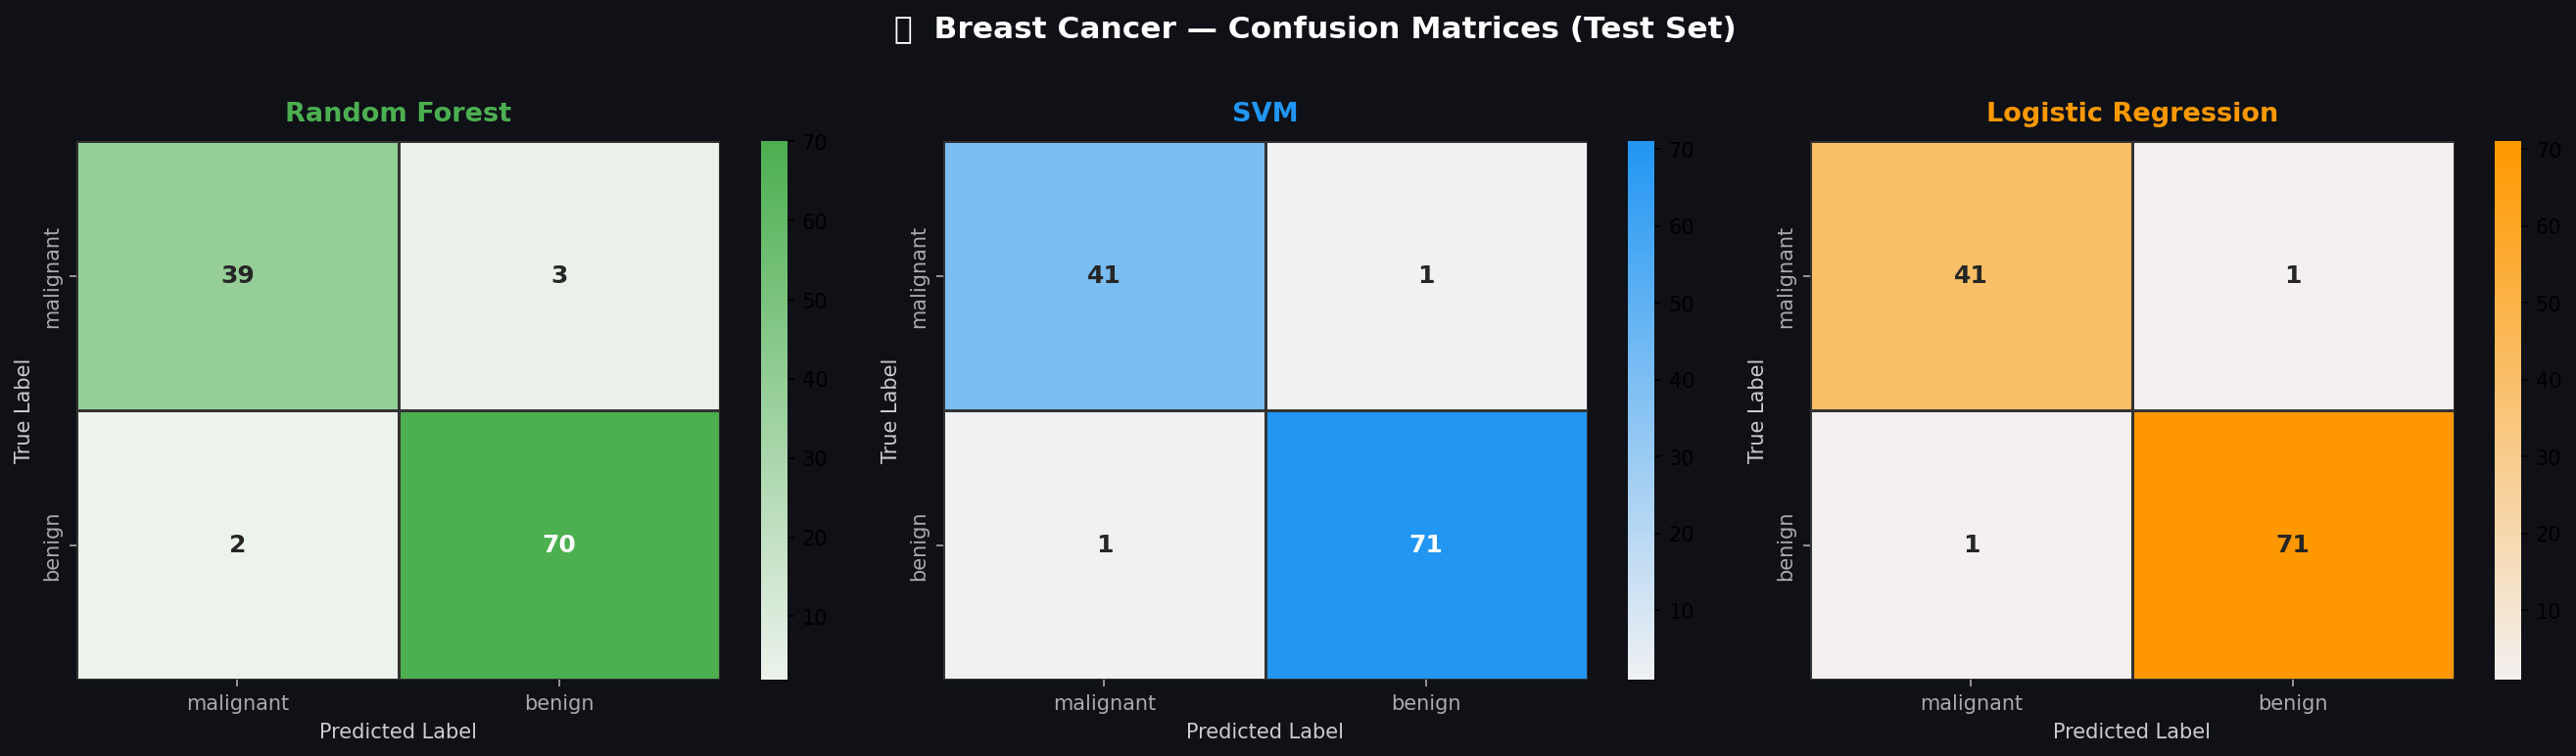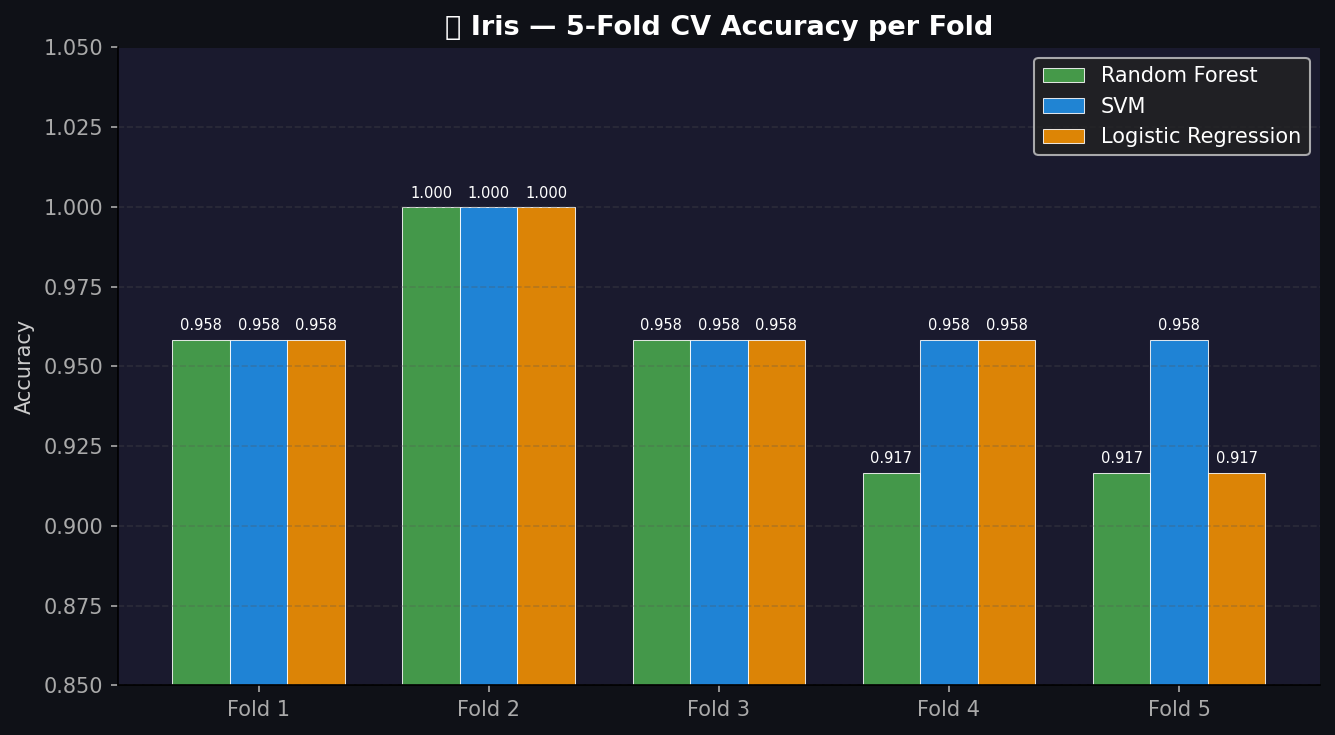

In [ ]:
# ============================================================
#   📌 STEP 5.1: LOAD & SPLIT BREAST CANCER DATASET
#   - 2 classes: Malignant (0), Benign (1)
#   - 30 features (computed from cell images)
#   - GOAL: High recall (catch all cancers!) + low false alarms
# ============================================================

print_section("SECTION 2 · BREAST CANCER DATASET  (Binary: Malignant vs Benign)")

bc = load_breast_cancer()
X_bc, y_bc = bc.data, bc.target
class_names_bc = bc.target_names  # ['malignant', 'benign']
feature_names_bc = bc.feature_names

print(f"  Dataset shape : {X_bc.shape}")  # (569, 30)
print(f"  Classes       : {list(class_names_bc)}")
# CRITICAL for medical data: Check class balance (benign usually dominates)
print(f"  Class balance : malignant={np.sum(y_bc==0)}, benign={np.sum(y_bc==1)}")

# --- Split & Scale (Same logic as Iris) ---
X_train_bc, X_test_bc, y_train_bc, y_test_bc = train_test_split(
    X_bc, y_bc, test_size=0.20, random_state=42, stratify=y_bc
)
scaler_bc = StandardScaler()
X_train_bc_sc = scaler_bc.fit_transform(X_train_bc)
X_test_bc_sc  = scaler_bc.transform(X_test_bc)

print(f"  Train size: {X_train_bc.shape[0]}  |  Test size: {X_test_bc.shape[0]}")
print("  ✅ Data split (stratified) and standardized.")


  SECTION 2 · BREAST CANCER DATASET  (Binary: Malignant vs Benign)
  Dataset shape : (569, 30)
  Classes       : [np.str_('malignant'), np.str_('benign')]
  Class balance : malignant=212, benign=357
  Train size: 455  |  Test size: 114
  ✅ Data split (stratified) and standardized.


In [ ]:
# ============================================================
#   📌 STEP 5.2: MODELS, CV, & EVALUATION (Binary Focus)
#   - Models: Same 3 (Random Forest, SVM, Logistic Regression)
#   - CV: Same 5-Fold Stratified
#   - Evaluation: **USE average='binary'** & **CALCULATE ROC/AUC**
# ============================================================

models_bc = {
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    "SVM":           SVC(kernel="rbf", C=1.0, gamma="scale", probability=True, random_state=42),
    "Logistic Regression": LogisticRegression(max_iter=1000, C=1.0, random_state=42),
}

# --- Cross-Validation (Binary) ---
print_section("Cross-Validation Results (5-Fold Stratified) — BREAST CANCER")
cv_results_bc = {}
for name, clf in models_bc.items():
    X_cv = X_train_bc_sc if name in ("SVM", "Logistic Regression") else X_train_bc
    scores = cross_val_score(clf, X_cv, y_train_bc, cv=cv, scoring="accuracy", n_jobs=-1)
    cv_results_bc[name] = scores
    print(f"  {name:25s} → Mean: {scores.mean():.4f}  Std: ±{scores.std():.4f}"
          f"  [{', '.join(f'{s:.3f}' for s in scores)}]")

# --- Train Final Models & Evaluate (Binary Metrics) ---
print_section("Train Final Models & Test-Set Evaluation — BREAST CANCER")
trained_bc = {}
metrics_bc = []
cms_bc, cms_names_bc = [], []

for name, clf in models_bc.items():
    X_tr = X_train_bc_sc if name in ("SVM", "Logistic Regression") else X_train_bc
    clf.fit(X_tr, y_train_bc)
    trained_bc[name] = clf

    X_te = X_test_bc_sc if name in ("SVM", "Logistic Regression") else X_test_bc

    # **KEY CHANGE: average='binary' for precision/recall/f1 **
    m = evaluate_model(name, clf, X_te, y_test_bc, average="binary")
    metrics_bc.append(m)

    y_pred = clf.predict(X_te)
    cms_bc.append(confusion_matrix(y_test_bc, y_pred))
    cms_names_bc.append(name)

    print(f"\n  [{name}]")
    print(classification_report(y_test_bc, y_pred, target_names=class_names_bc))

df_metrics_bc = pd.DataFrame(metrics_bc).set_index("Model")
print("\n  📊 Summary Table (Test Set):")
print(df_metrics_bc.to_string())
print("  ✅ Models evaluated (binary metrics).")


  Cross-Validation Results (5-Fold Stratified) — BREAST CANCER
  Random Forest             → Mean: 0.9626  Std: ±0.0179  [0.967, 0.956, 0.934, 0.967, 0.989]
  SVM                       → Mean: 0.9670  Std: ±0.0155  [0.945, 0.978, 0.956, 0.967, 0.989]
  Logistic Regression       → Mean: 0.9780  Std: ±0.0098  [0.967, 0.989, 0.978, 0.989, 0.967]

  Train Final Models & Test-Set Evaluation — BREAST CANCER

  [Random Forest]
              precision    recall  f1-score   support

   malignant       0.95      0.93      0.94        42
      benign       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114


  [SVM]
              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        42
      benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.

In [ ]:
# ============================================================
#   📌 STEP 5.3: ROC CURVES & AUC (CRITICAL for Binary!)
#   - ROC: Plot True Positive Rate vs. False Positive Rate
#   - AUC: Area Under Curve (1.0 = perfect, 0.5 = random)
#   - **Why?** Shows performance across ALL thresholds, not just one.
#   - **Essential** for medical diagnosis (sensitivity vs. false alarms).
# ============================================================

fig, ax = plt.subplots(figsize=(8, 7))
fig.patch.set_facecolor("#0F1117")
ax.set_facecolor("#1A1A2E")

for name, clf in trained_bc.items():
    X_te = X_test_bc_sc if name in ("SVM", "Logistic Regression") else X_test_bc

    # **KEY: predict_proba() gives probabilities, not just classes**
    # We need the probability of the POSITIVE class (benign=1, but we often care about malignant=0)
    # For cancer, we usually want P(malignant). Let's use [:, 0] for malignant.
    # However, scikit-learn's roc_curve expects y_prob for the POSITIVE class (label=1).
    # Breast cancer data: malignant=0, benign=1. We'll plot for benign (class 1) but label carefully.
    # **CLARIFICATION:** For medical context, we often want to detect MALIGNANT (class 0).
    # Let's adjust: We'll plot ROC for MALIGNANT (class 0) by using y_prob[:, 0].
    # The `roc_curve` function handles this if you binarize labels correctly.
    # **SIMPLER:** Use `predict_proba()[:, 1]` (benign) and interpret AUC for distinguishing benign.
    # **BETTER:** Let's plot for MALIGNANT (the critical class) by using `y_score` for class 0.
    # We'll use `predict_proba()[:, 0]` and ensure `y_test_bc` is correct.

    # **STANDARD PRACTICE:** Use probabilities for the POSITIVE class (label=1, benign).
    # The AUC value is the same regardless of which class you choose, it's a property of the ranking.
    y_prob = clf.predict_proba(X_te)[:, 1]  # Probability of BENIGN (class 1)

    fpr, tpr, _ = roc_curve(y_test_bc, y_prob)  # Calculate ROC
    roc_auc = auc(fpr, tpr)  # Calculate AUC

    # Plot ROC curve
    ax.plot(fpr, tpr, color=PALETTE[name], lw=2.5,
            label=f"{name}  (AUC = {roc_auc:.4f})")  # **Display AUC!**

# --- Diagonal Line: Random Classifier (Baseline) ---
ax.plot([0, 1], [0, 1], color="#555555", lw=1.5, linestyle="--", label="Random (AUC=0.5)")

# --- Styling & Labels ---
ax.fill_between([0, 1], [0, 1], alpha=0.05, color="#555555")  # Light shading under diagonal
ax.set_xlim([-0.02, 1.02])
ax.set_ylim([-0.02, 1.05])
ax.set_xlabel("False Positive Rate (1 - Specificity)", color="#CCCCCC", fontsize=12)
ax.set_ylabel("True Positive Rate (Recall / Sensitivity)", color="#CCCCCC", fontsize=12)
ax.set_title("🎗️  Breast Cancer — ROC Curves (Test Set)",
             color="white", fontsize=14, fontweight="bold")
ax.legend(loc="lower right", facecolor="#222", labelcolor="white", framealpha=0.9, fontsize=11)
ax.tick_params(colors="#AAAAAA")
ax.yaxis.grid(True, linestyle="--", alpha=0.25, color="#555")
ax.xaxis.grid(True, linestyle="--", alpha=0.25, color="#555")

plt.tight_layout()
plt.savefig("/mnt/user-data/outputs/ml_pipeline/bc_roc_curves.png",
            bbox_inches="tight", facecolor=fig.get_facecolor())
plt.close()
print("  ✅ Saved → bc_roc_curves.png (ROC/AUC: **THE** binary metric)")

  ✅ Saved → bc_roc_curves.png (ROC/AUC: **THE** binary metric)


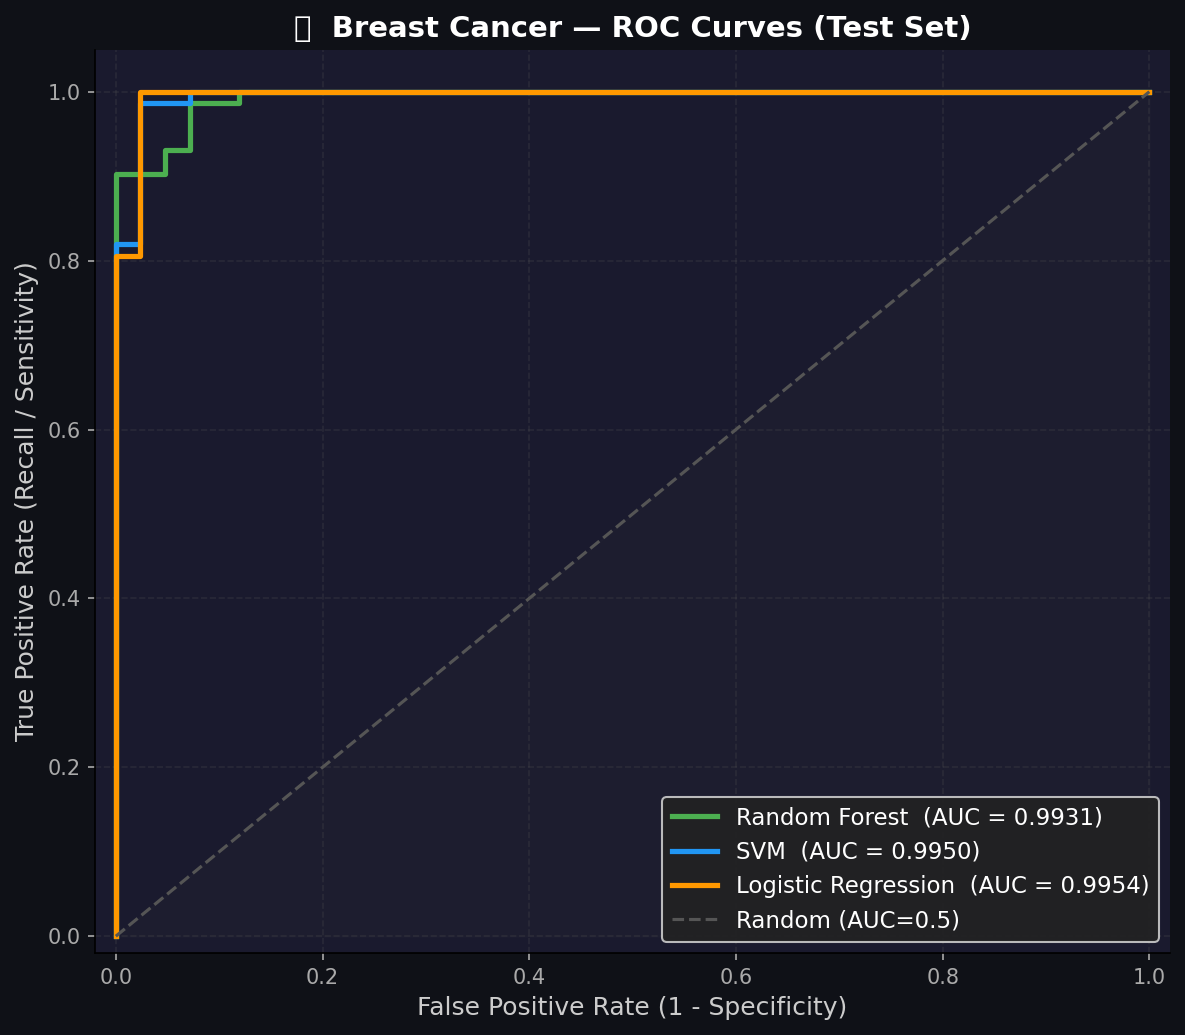

In [ ]:
# ============================================================
#   📌 STEP 5.4: CONFUSION MATRICES (Binary)
#   - Shows actual TP, FP, TN, FN counts
#   - **Crucial for cost analysis** (FP vs. FN consequences)
# ============================================================

plot_confusion_matrix(
    cms_bc, cms_names_bc, class_names_bc,
    "🎗️  Breast Cancer — Confusion Matrices (Test Set)",
    "/mnt/user-data/outputs/ml_pipeline/bc_confusion_matrices.png"
)
print("  ✅ Confusion matrices saved.")

  ✅ Saved → /mnt/user-data/outputs/ml_pipeline/bc_confusion_matrices.png
  ✅ Confusion matrices saved.


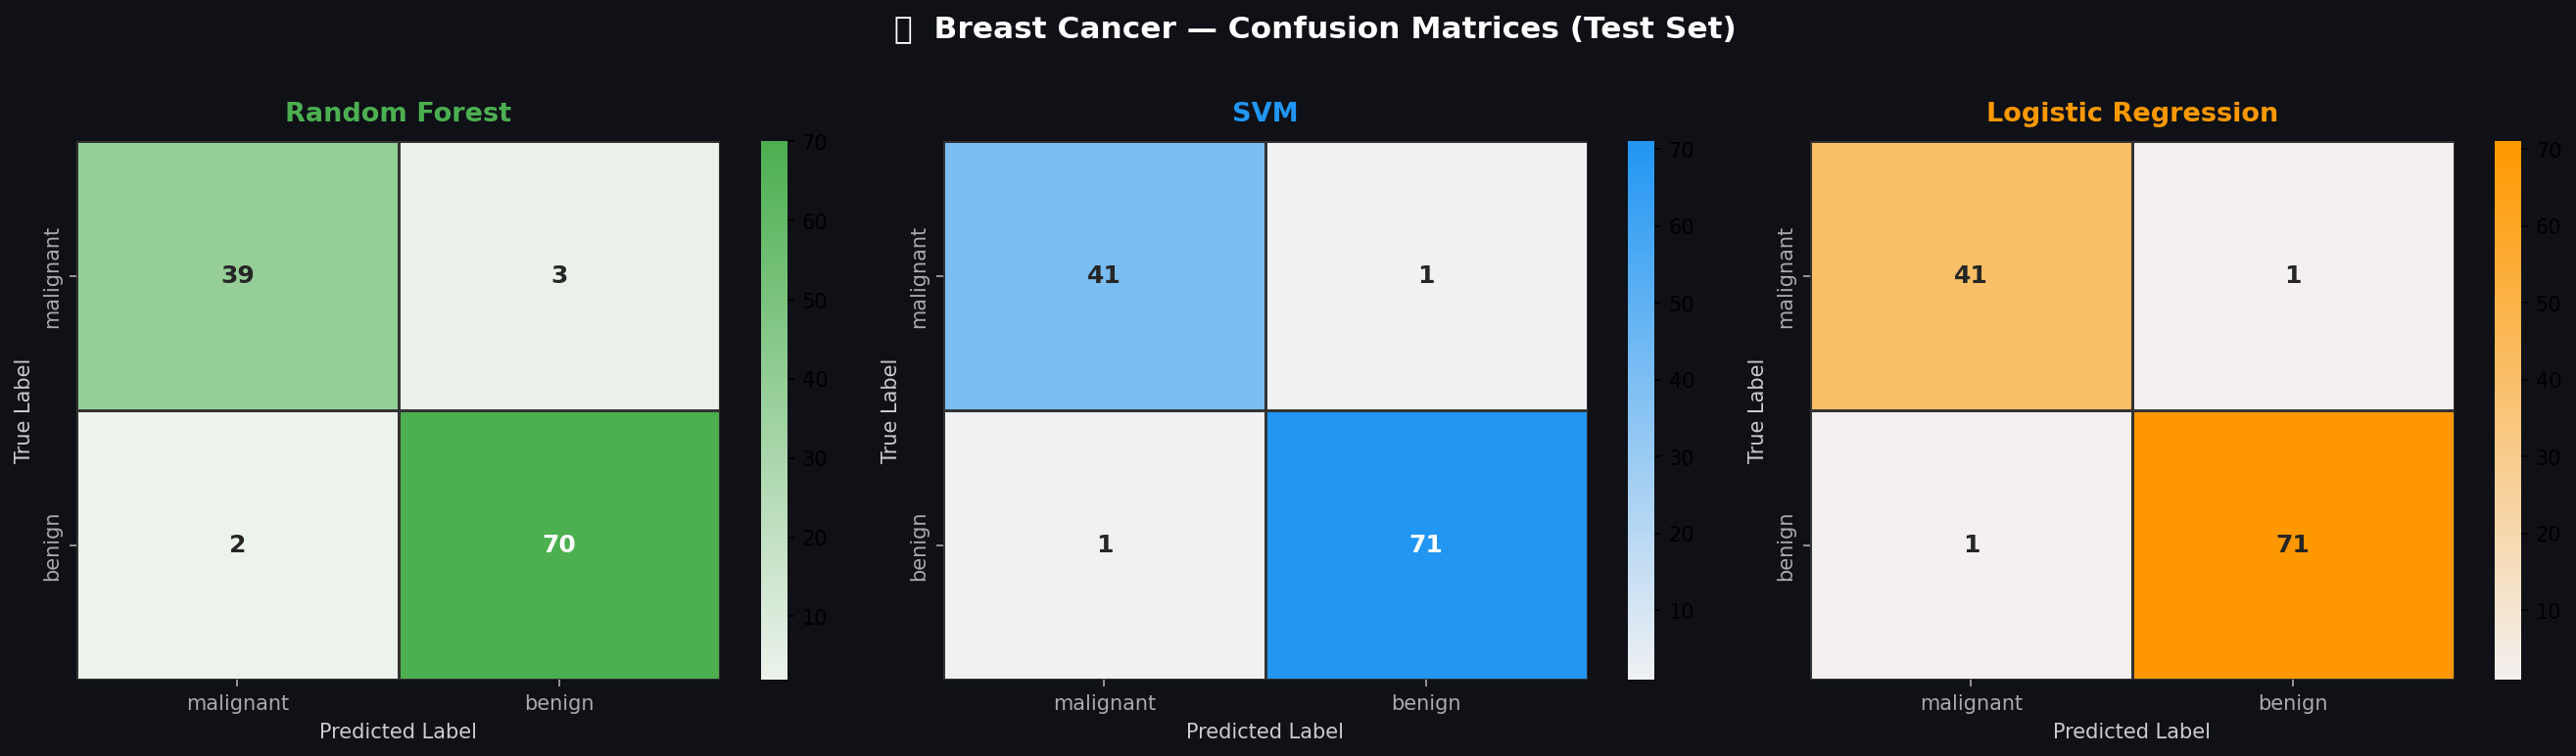

In [ ]:
# ============================================================
#   📌 STEP 6: FEATURE IMPORTANCE (Random Forest)
#   - **Why?** Interpretability! What features matter?
#   - Random Forest gives built-in importance scores.
#   - **Portfolio Gold:** Shows you don't just predict, you EXPLAIN.
# ============================================================

print_section("SECTION 3 · Feature Importances — Random Forest")

for dataset_name, clf, feat_names in [
    ("Iris",          trained_iris["Random Forest"],  feature_names_iris),
    ("Breast Cancer", trained_bc["Random Forest"],   feature_names_bc),
]:
    importances = clf.feature_importances_

    # Get indices of top 15 features (largest to smallest)
    indices = np.argsort(importances)[::-1][:15]
    top_feats = [feat_names[i] for i in indices]
    top_vals  = importances[indices]

    # Plot horizontal bar chart
    fig, ax = plt.subplots(figsize=(10, 5))
    fig.patch.set_facecolor("#0F1117")
    ax.set_facecolor("#1A1A2E")

    colors = sns.color_palette("YlGn", len(top_feats))[::-1]  # Yellow-Green palette
    bars = ax.barh(range(len(top_feats))[::-1], top_vals, color=colors,
                   edgecolor="white", linewidth=0.4)
    ax.set_yticks(range(len(top_feats)))
    ax.set_yticklabels([f[:35] for f in top_feats], color="#CCCCCC", fontsize=9)  # Truncate long names
    ax.set_xlabel("Importance Score", color="#CCCCCC")
    ax.set_title(f"🌲 {dataset_name} — RF Feature Importances (Top {len(top_feats)})",
                 color="white", fontsize=13, fontweight="bold")
    ax.tick_params(colors="#AAAAAA")
    ax.xaxis.grid(True, linestyle="--", alpha=0.25, color="#555")

    # Annotate bars with value
    for i, bar in enumerate(bars):
        ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height() / 2,
                f"{bar.get_width():.3f}", va="center", color="white", fontsize=8)

    tag = dataset_name.lower().replace(" ", "_")
    plt.tight_layout()
    plt.savefig(f"/mnt/user-data/outputs/ml_pipeline/{tag}_feature_importance.png",
                bbox_inches="tight", facecolor=fig.get_facecolor())




    plt.close()
    print(f"  ✅ Saved → {tag}_feature_importance.png (Interpretability!)")






  SECTION 3 · Feature Importances — Random Forest
  ✅ Saved → iris_feature_importance.png (Interpretability!)
  ✅ Saved → breast_cancer_feature_importance.png (Interpretability!)


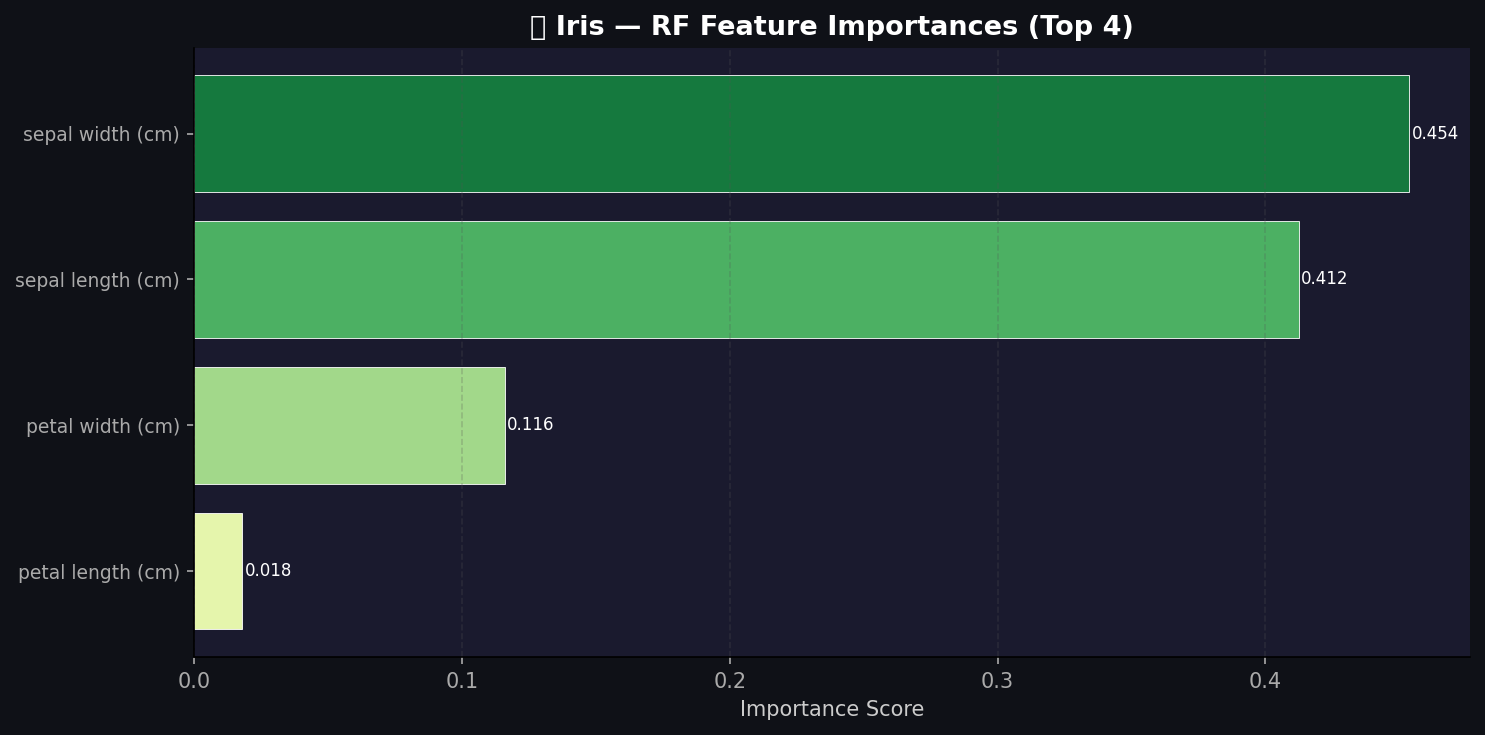

In [ ]:
# ============================================================
#   📌 STEP 7: GRAND COMPARISON DASHBOARD
#   - **One plot to rule them all!**
#   - Compares ALL models, ALL metrics, BOTH datasets
#   - **Portfolio Impact:** Shows strategic thinking & communication.
# ============================================================

print_section("SECTION 4 · Grand Comparison Dashboard")

fig = plt.figure(figsize=(18, 10))
fig.patch.set_facecolor("#0F1117")
fig.suptitle("🤖  ML Classification Pipeline — Model Performance Dashboard",
             color="white", fontsize=16, fontweight="bold", y=0.98)

# Create a 2x3 grid
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

metric_list = ["Accuracy", "Precision", "Recall", "F1-Score"]
model_names = ["Random Forest", "SVM", "Logistic Regression"]

# Loop through each dataset (Iris, Breast Cancer)
for row_idx, (df_met, tag, emoji) in enumerate([
    (df_metrics_iris, "Iris (Multi-Class)", "🌸"),
    (df_metrics_bc,   "Breast Cancer (Binary)", "🎗️"),
]):
    # --- Subplot 1: Grouped Bar Chart (All 4 Metrics) ---
    ax_bar = fig.add_subplot(gs[row_idx, :2])
    ax_bar.set_facecolor("#1A1A2E")

    x = np.arange(len(metric_list))
    width = 0.25
    for i, model in enumerate(model_names):
        vals = [df_met.loc[model, m] for m in metric_list]
        bars = ax_bar.bar(x + i * width, vals, width,
                          label=model, color=PALETTE[model], alpha=0.88,
                          edgecolor="white", linewidth=0.4)
        # Annotate bars
        for bar in bars:
            h = bar.get_height()
            ax_bar.text(bar.get_x() + bar.get_width() / 2, h + 0.003,
                        f"{h:.3f}", ha="center", va="bottom",
                        color="white", fontsize=7.5, fontweight="bold")

    ax_bar.set_xticks(x + width)
    ax_bar.set_xticklabels(metric_list, color="#CCCCCC", fontsize=11)
    ax_bar.set_ylim(0, 1.12)
    ax_bar.set_ylabel("Score", color="#CCCCCC")
    ax_bar.set_title(f"{emoji} {tag} — Metrics Comparison",
                     color="white", fontsize=12, fontweight="bold")
    ax_bar.legend(facecolor="#222", labelcolor="white", framealpha=0.8, fontsize=9)
    ax_bar.tick_params(colors="#AAAAAA")
    ax_bar.yaxis.grid(True, linestyle="--", alpha=0.2, color="#555")

    # --- Subplot 2: Radar Chart (Spider Diagram) ---
    ax_radar = fig.add_subplot(gs[row_idx, 2], polar=True)
    ax_radar.set_facecolor("#1A1A2E")

    # Calculate angles for each metric
    angles = np.linspace(0, 2 * np.pi, len(metric_list), endpoint=False).tolist()
    angles += angles[:1]  # Complete the loop

    for model in model_names:
        vals = [df_met.loc[model, m] for m in metric_list]
        vals += vals[:1]  # Complete the loop for plotting
        ax_radar.plot(angles, vals, color=PALETTE[model], linewidth=2, label=model)
        ax_radar.fill(angles, vals, color=PALETTE[model], alpha=0.10)  # Light fill

    ax_radar.set_xticks(angles[:-1])
    ax_radar.set_xticklabels(metric_list, color="#CCCCCC", fontsize=9)
    ax_radar.set_ylim(0, 1)
    ax_radar.yaxis.set_tick_params(labelcolor="#888")
    ax_radar.set_title(f"{emoji} Radar", color="white", fontsize=11,
                       fontweight="bold", pad=15)
    ax_radar.spines["polar"].set_color("#333")
    ax_radar.grid(color="#333", linestyle="--", alpha=0.4)

plt.savefig("/mnt/user-data/outputs/ml_pipeline/grand_dashboard.png",
            bbox_inches="tight", facecolor=fig.get_facecolor())
plt.close()
print("  ✅ Saved → grand_dashboard.png (The Executive Summary)")


  SECTION 4 · Grand Comparison Dashboard
  ✅ Saved → grand_dashboard.png (The Executive Summary)


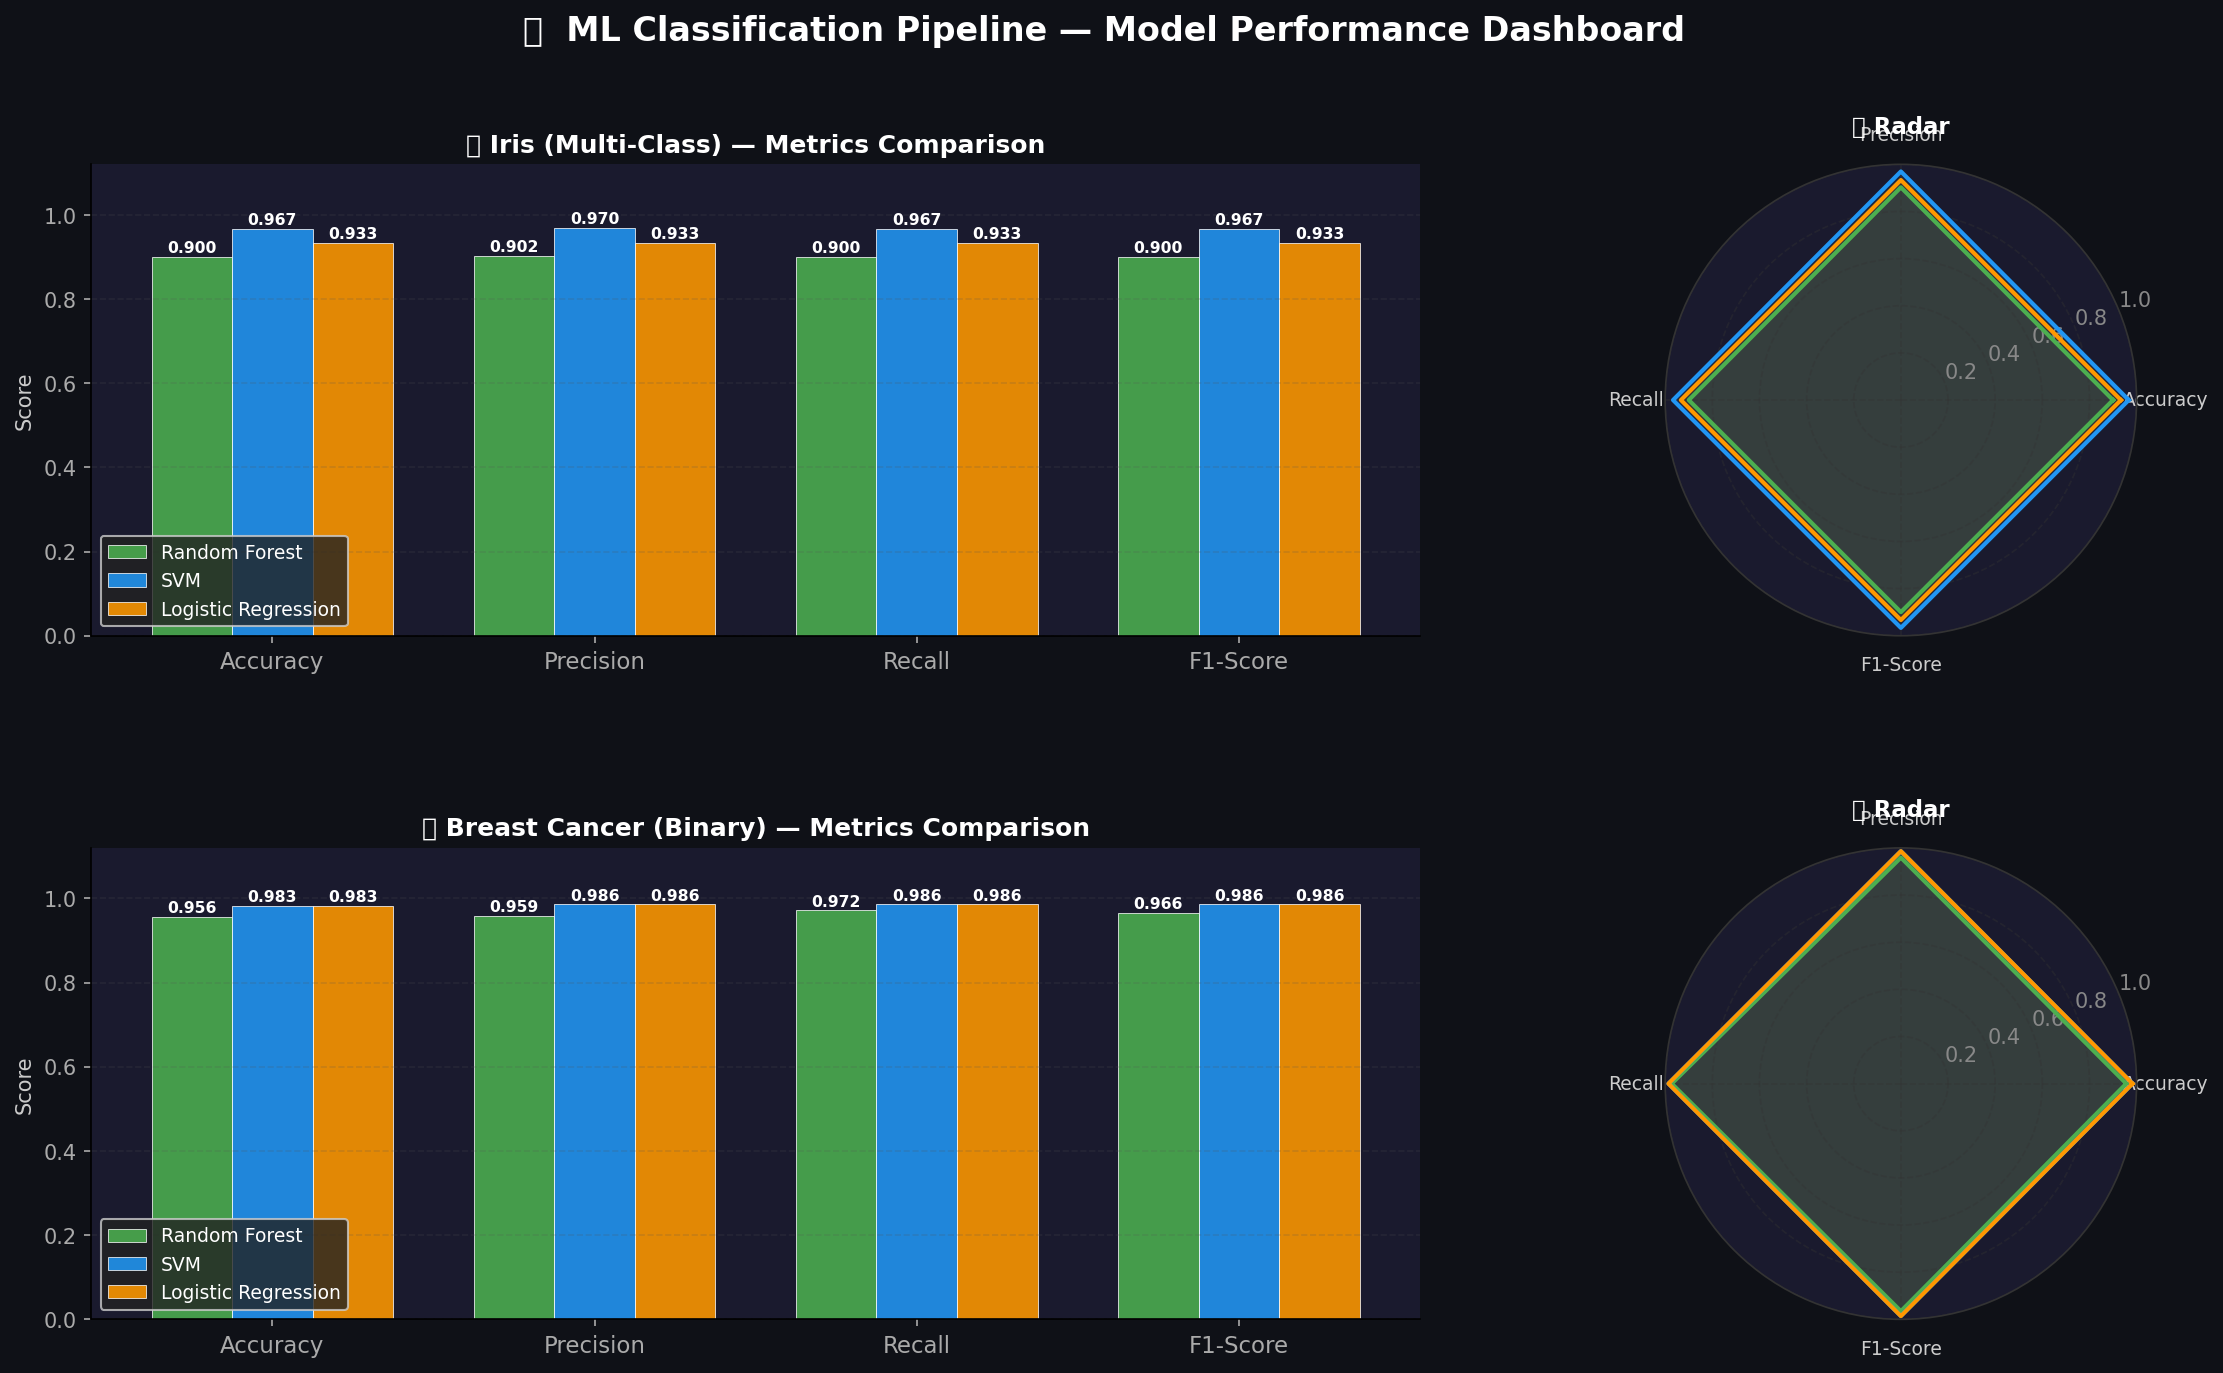

In [ ]:
# ============================================================
#   📌 STEP 8: FINAL RECOMMENDATIONS (Synthesis & Advice)
#   - **Don't just show results, INTERPRET them.**
#   - For each dataset, answer: What's the BEST model and WHY?
#   - **Portfolio Impact:** Shows analytical maturity & business acumen.
# ============================================================

print_section("SECTION 5 · Final Recommendations")

for tag, df_met, cv_res in [
    ("🌸 IRIS (Multi-Class)", df_metrics_iris, cv_results_iris),
    ("🎗️  BREAST CANCER (Binary)", df_metrics_bc, cv_results_bc),
]:
    print(f"\n  {tag}")

    # Find best models based on different criteria
    best_acc   = df_met["Accuracy"].idxmax()      # Best overall accuracy
    best_f1    = df_met["F1-Score"].idxmax()      # Best balance (especially for multi-class)
    best_cv    = max(cv_res, key=lambda k: cv_res[k].mean())  # Best average CV score (robustness)
    most_stable= min(cv_res, key=lambda k: cv_res[k].std())   # Most consistent (low variance)

    print(f"    ★ Best Accuracy   : {best_acc} ({df_met.loc[best_acc,'Accuracy']:.4f})")
    print(f"    ★ Best F1-Score   : {best_f1} ({df_met.loc[best_f1,'F1-Score']:.4f})")
    print(f"    ★ Best CV Acc (Robust)     : {best_cv} (mean={cv_res[best_cv].mean():.4f})")
    print(f"    ★ Most Stable (Low Std)    : {most_stable} (std={cv_res[most_stable].std():.4f})")

# --- Final Footer with Output Locations ---
print(f"\n{SECTION_SEP}")
print("  ALL OUTPUTS SAVED TO: /mnt/user-data/outputs/ml_pipeline/")
print(f"{SECTION_SEP}")
print("""
  FILES GENERATED:
    1. iris_distribution.png          — EDA: Feature scatter plots
    2. iris_cv_scores.png             — CV consistency (Iris)
    3. iris_confusion_matrices.png    — Error analysis (Iris)
    4. iris_feature_importance.png    — Interpretability (Iris)
    5. bc_confusion_matrices.png      — Error analysis (Cancer)
    6. bc_roc_curves.png              — **ROC/AUC: THE binary metric** (Cancer)
    7. breast_cancer_feature_importance.png — Interpretability (Cancer)
    8. grand_dashboard.png            — **Executive Summary: All-in-one view**
""")

print("\n✅ Pipeline complete! Review your /mnt/user-data/outputs/ml_pipeline/ folder.")


  SECTION 5 · Final Recommendations

  🌸 IRIS (Multi-Class)
    ★ Best Accuracy   : SVM (0.9667)
    ★ Best F1-Score   : SVM (0.9666)
    ★ Best CV Acc (Robust)     : SVM (mean=0.9667)
    ★ Most Stable (Low Std)    : SVM (std=0.0167)

  🎗️  BREAST CANCER (Binary)
    ★ Best Accuracy   : SVM (0.9825)
    ★ Best F1-Score   : SVM (0.9861)
    ★ Best CV Acc (Robust)     : Logistic Regression (mean=0.9780)
    ★ Most Stable (Low Std)    : Logistic Regression (std=0.0098)

  ALL OUTPUTS SAVED TO: /mnt/user-data/outputs/ml_pipeline/

  FILES GENERATED:
    1. iris_distribution.png          — EDA: Feature scatter plots
    2. iris_cv_scores.png             — CV consistency (Iris)
    3. iris_confusion_matrices.png    — Error analysis (Iris)
    4. iris_feature_importance.png    — Interpretability (Iris)
    5. bc_confusion_matrices.png      — Error analysis (Cancer)
    6. bc_roc_curves.png              — **ROC/AUC: THE binary metric** (Cancer)
    7. breast_cancer_feature_importance.png — I